In [6]:
%matplotlib inline 

In [7]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_simpler_mesh_dense_copy" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")



def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# # Add code to keep .gitignore updated to ignore salvus files
# gitignore_path = pathlib.Path("..") / ".gitignore"
# with open(gitignore_path, "r+") as f:
#     contents = f.read()
#     if PROJECT_DIR not in contents:
#         f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [8]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [9]:


# Simulation constants
f0 = 20.0
sampling_rate = 10000.0
dt = 1.0 / sampling_rate

step = 50.0
x_positions = np.arange(30.0, 270.0, step)
target_vprop = 90.0
delay_between_sources = step / target_vprop
print(f"Time step between sources: {delay_between_sources:.4f} s")

y_src = 2.625

# Shared time setup (half width can be the same for all the wavelets )
half_width = 0.08
pre_delay = half_width

last_source_delay = (len(x_positions) - 1) * delay_between_sources
t_max = pre_delay + last_source_delay + half_width + 0.5
t_sim = np.arange(0, t_max, dt)
print(f"t_sim length: {len(t_sim)} samples, duration: {t_sim[-1]:.3f} s")

t_local = np.arange(-half_width, half_width, dt)
half_samples = len(t_local) // 2

# Define Bases of wavelets
# Ricker 
ricker_base = (
    (1.0 - 2.0 * (np.pi * f0 * t_local) ** 2)
    * np.exp(-((np.pi * f0 * t_local) ** 2))
)

# Morlet
morlet_base = (
    np.exp(-((t_local / half_width) ** 2)) 
    * np.cos(2 * np.pi * f0 * t_local)
)

# Gaussian
gaussian_base = np.exp(-((t_local / half_width) ** 2))


# Weigths setup
base_mxx =  1.0
base_myy = -1.0
base_mxy =  1.0

srcs = []

random_weight_xx = np.ones(len(x_positions)) 
random_weight_yy = np.ones(len(x_positions))
random_weight_xy = np.ones(len(x_positions))

weight_array = np.array([random_weight_xx, random_weight_yy, random_weight_xy]).T

# Main source setup
for i, x_src in enumerate(x_positions):
    center_time = pre_delay + i * delay_between_sources
    center_sample = int(round(center_time * sampling_rate))

    start_idx = center_sample - half_samples
    end_idx   = center_sample + half_samples

    # Initialize empty arrays for the delayed wavelets
    ricker_delayed = np.zeros(len(t_sim))
    morlet_delayed = np.zeros(len(t_sim))
    gaussian_delayed = np.zeros(len(t_sim))

    if end_idx > 0 and start_idx < len(t_sim):
        sim_start = max(0, start_idx)
        sim_end   = min(len(t_sim), end_idx)
        wav_start = max(0, -start_idx)
        wav_end   = wav_start + (sim_end - sim_start)
        
        # Shift all three wavelets into the simulation time window
        ricker_delayed[sim_start:sim_end]   = ricker_base[wav_start:wav_end]
        morlet_delayed[sim_start:sim_end]   = morlet_base[wav_start:wav_end]
        gaussian_delayed[sim_start:sim_end] = gaussian_base[wav_start:wav_end]

    # Sanity check for clipping (we only need to check one since they share dimensions)
    n_nonzero = np.count_nonzero(ricker_delayed)
    expected  = len(ricker_base)
    if n_nonzero < expected - 2:
        print(f"  WARNING source {i}: only {n_nonzero}/{expected} samples written — wavelets clipped!")

    # Construct stf array
    stf_vector_array = np.array([
        ricker_delayed   * (base_mxx * weight_array[i, 0]),
        morlet_delayed   * (base_myy * weight_array[i, 1]),
        gaussian_delayed * (base_mxy * weight_array[i, 2]),
    ])

    stf_xx = sc.stf.Custom.from_array(array=ricker_delayed * base_mxx * weight_array[i, 0], sampling_rate_in_hertz=sampling_rate)
    stf_yy = sc.stf.Custom.from_array(array=morlet_delayed * base_myy * weight_array[i, 1], sampling_rate_in_hertz=sampling_rate)
    stf_xy = sc.stf.Custom.from_array(array=gaussian_delayed * base_mxy * weight_array[i, 2], sampling_rate_in_hertz=sampling_rate)

    srcs.append(sc.source.cartesian.MomentTensorPoint2D(x=x_src, y=y_src, mxx=1.0, myy=0.0, mxy=0.0, source_time_function=stf_xx))
    srcs.append(sc.source.cartesian.MomentTensorPoint2D(x=x_src, y=y_src, mxx=0.0, myy=1.0, mxy=0.0, source_time_function=stf_yy))
    srcs.append(sc.source.cartesian.MomentTensorPoint2D(x=x_src, y=y_src, mxx=0.0, myy=0.0, mxy=1.0, source_time_function=stf_xy))

    plotting_steps = np.arange(0, len(x_positions), 5)
   


print(f"\nGenerated {len(srcs)} sources.")
print(f"First source centred at: {pre_delay:.4f} s")
print(f"Last  source centred at: {pre_delay + (len(srcs)-1)*delay_between_sources:.4f} s")
print(f"t_sim spans 0 to {t_sim[-1]:.3f} s")

Time step between sources: 0.5556 s
t_sim length: 28823 samples, duration: 2.882 s

Generated 15 sources.
First source centred at: 0.0800 s
Last  source centred at: 7.8578 s
t_sim spans 0 to 2.882 s


In [10]:
srcs

[{'location': [30.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2606301501269129fa8cacc5__1128355/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 0.0, 0.0]},
 {'location': [30.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__260630150127025071b21c17__1128355/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [0.0, 1.0, 0.0]},
 {'location': [30.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__26063015012716400e652143__1128355/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 

In [11]:
import h5py


h5_path = srcs[0].source_time_function.filename
dataset_name = srcs[0].source_time_function.dataset_name
wavelet_type = srcs[0].source_time_function.wavelet

print(f"Wavelet Type: {wavelet_type}")
print(f"HDF5 File Location: {h5_path}")
print(f"Dataset Name inside HDF5: {dataset_name}\n")

# Open  file to look at the raw custom wavelet data structure
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    
    print("--- Dataset Details ---")
    print("Array Shape (n_components, n_samples):", dset.shape)
    print("Data Type:", dset.dtype)
    
    print("\n--- Meta-Data Attributes Attached by Salvus ---")
    for key, val in dset.attrs.items():
        print(f"  {key}: {val}")
        
    # first 10 numerical values of the actual wavelet array
    print("\nFirst 10 amplitude values of the custom array:")
    print(dset[:10])

    

Wavelet Type: custom
HDF5 File Location: /tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2606301501269129fa8cacc5__1128355/custom_stf.h5
Dataset Name inside HDF5: /stf

--- Dataset Details ---
Array Shape (n_components, n_samples): (28823, 1)
Data Type: float64

--- Meta-Data Attributes Attached by Salvus ---
  sampling_rate_in_hertz: 10000.0
  start_time_in_seconds: 0.0

First 10 amplitude values of the custom array:
[[-5.27136926e-10]
 [-5.60054552e-10]
 [-5.94978797e-10]
 [-6.32028857e-10]
 [-6.71330817e-10]
 [-7.13018033e-10]
 [-7.57231538e-10]
 [-8.04120472e-10]
 [-8.53842535e-10]
 [-9.06564464e-10]]


In [12]:


# Path and dataset pointer form object for first source 
h5_path = srcs[1].source_time_function.filename
dataset_name = srcs[1].source_time_function.dataset_name

# Extract the array and metadata from the HDF5 file
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    stf_array = np.squeeze(dset[:]) # Squeeze removes empty dimensions 
    
    # Extract attributes
    sampling_rate = dset.attrs.get('sampling_rate_in_hertz', 10000.0)
    start_time = dset.attrs.get('start_time_in_seconds', 0.0)

# Time axis of soutce 
dt = 1.0 / sampling_rate
time_axis = start_time + (np.arange(len(stf_array)) * dt)


plt.figure(figsize=(10, 4))
plt.plot(time_axis, stf_array, color='crimson', lw=1.5)
plt.xlabel('Simulation Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Custom STF Waveform (Extracted from Salvus HDF5)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [14]:

# Layered model setup: three layers ordered as snow, slab, air (top to bottom).

x_min, x_max = 0.0, 400.0

# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([332.0, 300.0, 300.0]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)
 
max_frequency = np.percentile([vp[0], vp[1], vp[2]], 95) # set this as the 95th percentile of the expected frequency content
print(f"Max frequency for meshing: {max_frequency:.1f} Hz")
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=4,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")


Max frequency for meshing: 328.8 Hz
Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=150 m/s
  Weak layer: y = [2.25, 1.50] m, vs=150 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s


In [ ]:
# Initialize simulation object, pass multiple sources
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

# physics parameters 
sim.physics.wave_equation.end_time_in_seconds = 2.5
sim.physics.wave_equation.start_time_in_seconds = 0.05

sim.output.volume_data.format = "hdf5"
sim.output.volume_data.fields = ["displacement", "velocity"]
sim.output.volume_data.filename = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 50


moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")

print(f"Launching simulation. Outputs will be copied to: {moving_source_output_folder}")

# Launchg
salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True, 
)

print("Run finished successfully!")

Launching simulation. Outputs will be copied to: simulation_wavefield_custom_stf_simpler_mesh_dense_copy/custom_job_moving_source_all_sources
SalvusJob `job_2606301502600330_0467c80790` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/71100 [00:00<?, ?it/s]

In [ ]:
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-06-29 13:38:12,259] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded velocity from simulation_wavefield_custom_stf_simpler_mesh_dense_SUB/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 252, c: 2, x: 1601, y: 101)> Size: 326MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.0000000

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: 0.05 -> 4.006620640114934
vx shape: (252, 1601)
vy shape: (252, 1601)


/tmp/ipykernel_1031885/1095561471.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_1031885/1095561471.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


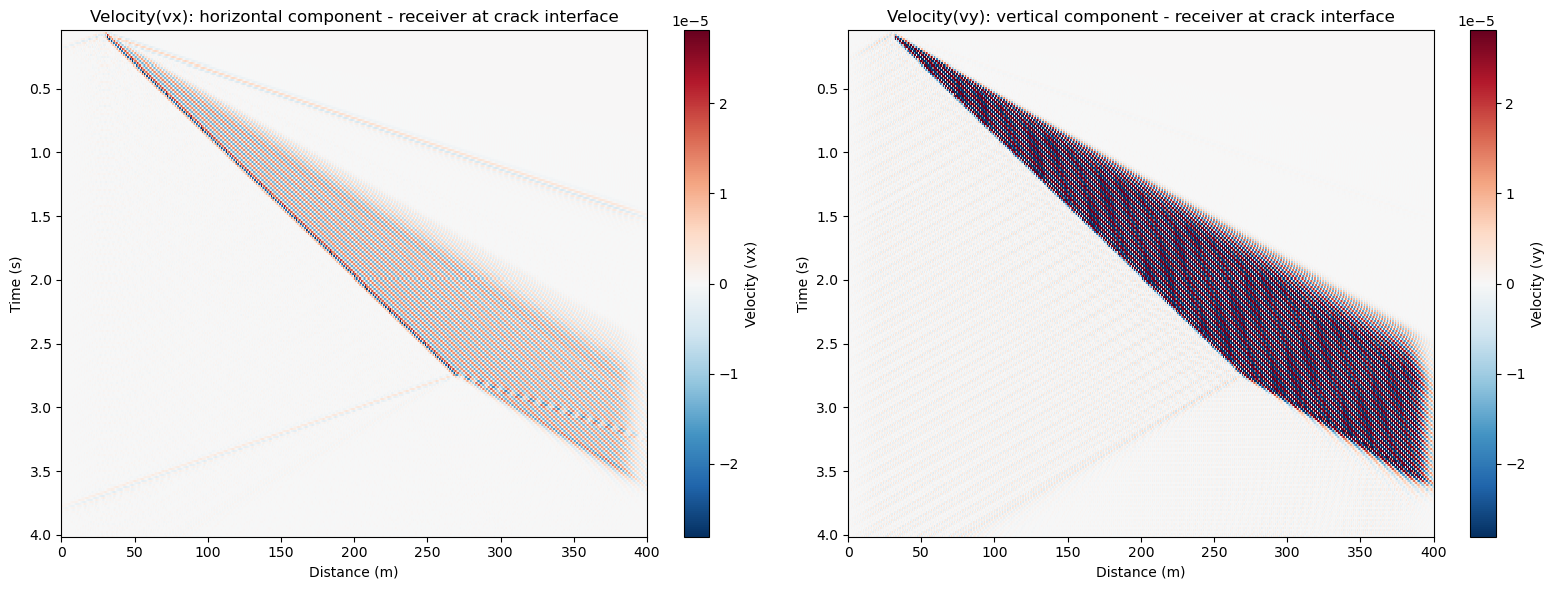

In [ ]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [ ]:
# animation 
# =============================================================================
# UNIFIED WAVEFIELD ANIMATION ENGINE (Vy & Vx)
# =============================================================================
import pathlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import display
from salvus.toolbox.helpers import wavefield_output

# Always reload the latest simulation output from disk
base_dir = globals().get('PROJECT_DIR', "simulation_wavefield_custom_stf_weighted_simpler_mesh_dense")
project_path = pathlib.Path(base_dir) / "custom_job_moving_source_all_sources"

output_candidates = sorted(project_path.glob("**/volume_data_output.h5"), key=lambda path: path.stat().st_mtime, reverse=True)
if not output_candidates:
    raise RuntimeError(f"Missing output file under {project_path}: volume_data_output.h5")
vol_file = output_candidates[0]
print(f"Using latest wavefield file: {vol_file}")

vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

# Resolve coordinate and dimension naming conventions robustly
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)
x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if None in [x_name, y_name, t_name, c_name]:
    raise ValueError(f"Could not resolve dimensions from dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

receiver_y = 2.625

# =============================================================================
# PART 1: VERTICAL VELOCITY COMPONENT (vy)
# =============================================================================
print("\n--- Processing Animation 1/2: Velocity (vy) ---")
vy_event = vel_2d_layered.isel({c_name: 1})  # Component 1 = vy
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals_y = vy_event[x_name].values
y_vals_y = vy_event[y_name].values
t_vals_y = vy_event[t_name].values
frames_3d_y = np.asarray(vy_event.values, dtype=np.float64)
frames_3d_y = np.nan_to_num(frames_3d_y, nan=0.0, posinf=0.0, neginf=0.0)

t_start_idx = np.searchsorted(t_vals_y, 0.0)
N = 8
raw_idx_y = np.arange(t_start_idx, frames_3d_y.shape[0], N)
max_frames = 350
t_idx_y = raw_idx_y[:max_frames]

# Robust symmetric color scaling
sample_abs_y = np.abs(frames_3d_y[t_idx_y]).ravel()
sample_abs_y = sample_abs_y[np.isfinite(sample_abs_y) & (sample_abs_y > 1e-14)]
vmax_y = max(float(np.percentile(sample_abs_y, 99.0)), 1e-8) if sample_abs_y.size > 0 else 1e-8
norm_y = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_y, vmax=vmax_y)

fig_y, ax_y = plt.subplots(figsize=(12, 4), constrained_layout=True)
im_y = ax_y.imshow(
    frames_3d_y[t_idx_y[0]],
    extent=[x_vals_y.min(), x_vals_y.max(), y_vals_y.max(), y_vals_y.min()],
    aspect="auto",
    cmap="RdBu_r",
    norm=norm_y,
    origin="upper",
    interpolation="nearest",
)

ax_y.axhline(1.5, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y=1.5 m)")
ax_y.set_xlabel("x (m)")
ax_y.set_ylabel("Depth (m)")
ax_y.set_xlim(x_vals_y.min(), x_vals_y.max())
ax_y.set_ylim(y_vals_y.max(), y_vals_y.min())
ax_y.legend(loc="upper right", fontsize=8)
plt.colorbar(im_y, ax=ax_y, label="Velocity (vy)", shrink=0.8)
title_y = ax_y.set_title(f"Wavefield Velocity(vy) - t = {t_vals_y[t_idx_y[0]]:.4f} s at snow bottom (y=2.25 m)")

def update_y(frame_idx):
    ti = t_idx_y[frame_idx]
    im_y.set_data(frames_3d_y[ti])
    title_y.set_text(f"Wavefield Velocity(vy) - t = {t_vals_y[ti]:.4f} s")
    return im_y, title_y

ani_y = animation.FuncAnimation(fig_y, update_y, frames=len(t_idx_y), interval=90, blit=False)
output_name_y = "custom_SUB_wavefield_2d_moving_vy_crack.gif"
print(f"Saving {output_name_y}...")
ani_y.save(output_name_y, writer=animation.PillowWriter(fps=15), dpi=80)
plt.close(fig_y)
print(f"Done! Saved as {output_name_y}")


# =============================================================================
# PART 2: HORIZONTAL VELOCITY COMPONENT (vx)
# =============================================================================
print("\n--- Processing Animation 2/2: Velocity (vx) ---")
vx_event = vel_2d_layered.isel({c_name: 0})  # Component 0 = vx
if e_name is not None and e_name in vx_event.dims:
    vx_event = vx_event.mean(dim=e_name)
vx_event = vx_event.transpose(t_name, y_name, x_name)

# Arrays are extracted purely from the independent vx_event structure
x_vals_x = vx_event[x_name].values
y_vals_x = vx_event[y_name].values
t_vals_x = vx_event[t_name].values
frames_3d_x = np.asarray(vx_event.values, dtype=np.float64)
frames_3d_x = np.nan_to_num(frames_3d_x, nan=0.0, posinf=0.0, neginf=0.0)

raw_idx_x = np.arange(np.searchsorted(t_vals_x, 0.0), frames_3d_x.shape[0], N)
t_idx_x = raw_idx_x[:max_frames]

sample_abs_x = np.abs(frames_3d_x[t_idx_x]).ravel()
sample_abs_x = sample_abs_x[np.isfinite(sample_abs_x) & (sample_abs_x > 1e-14)]
vmax_x = max(float(np.percentile(sample_abs_x, 99.0)), 1e-8) if sample_abs_x.size > 0 else 1e-8
norm_x = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_x, vmax=vmax_x)

fig_x, ax_x = plt.subplots(figsize=(12, 4), constrained_layout=True)
im_x = ax_x.imshow(
    frames_3d_x[t_idx_x[0]],
    extent=[x_vals_x.min(), x_vals_x.max(), y_vals_x.max(), y_vals_x.min()],
    aspect="auto",
    cmap="RdBu_r",
    norm=norm_x,
    origin="upper",
    interpolation="nearest",
)

ax_x.axhline(1.5, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y=1.5 m)")
ax_x.set_xlabel("x (m)")
ax_x.set_ylabel("Depth (m)")
ax_x.set_xlim(x_vals_x.min(), x_vals_x.max())
ax_x.set_ylim(y_vals_x.max(), y_vals_x.min())
ax_x.legend(loc="upper right", fontsize=8)
plt.colorbar(im_x, ax=ax_x, label="Velocity (vx)", shrink=0.8)
title_x = ax_x.set_title(f"Wavefield Velocity(vx) - t = {t_vals_x[t_idx_x[0]]:.4f} s at crack location (y = 2.625m)")

def update_x(frame_idx):
    ti = t_idx_x[frame_idx]
    im_x.set_data(frames_3d_x[ti])
    title_x.set_text(f"Wavefield Velocity(vx) - t = {t_vals_x[ti]:.4f} s")
    return im_x, title_x

ani_x = animation.FuncAnimation(fig_x, update_x, frames=len(t_idx_x), interval=90, blit=False)

if animation.writers.is_available("ffmpeg"):
    writer_x = animation.FFMpegWriter(
        fps=15,
        codec="libx264",
        extra_args=["-pix_fmt", "yuv420p", "-crf", "28"],
    )
    output_name_x = "custom_SUB_wavefield_2d_moving_vx_crack.mp4"
else:
    writer_x = animation.PillowWriter(fps=10)
    output_name_x = "custom_SUB_wavefield_2d_moving_vx_crack.gif"

print(f"Saving {output_name_x}...")
ani_x.save(output_name_x, writer=writer_x, dpi=80)
plt.close(fig_x)
print(f"Done! Saved as {output_name_x}")

Using latest wavefield file: simulation_wavefield_custom_stf_simpler_mesh_dense_SUB/custom_job_moving_source_all_sources/volume_data_output.h5


Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-06-29 13:38:30,453] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]


--- Processing Animation 1/2: Velocity (vy) ---
Saving custom_SUB_wavefield_2d_moving_vy_crack.gif...
Done! Saved as custom_SUB_wavefield_2d_moving_vy_crack.gif

--- Processing Animation 2/2: Velocity (vx) ---
Saving custom_SUB_wavefield_2d_moving_vx_crack.gif...


KeyboardInterrupt: 

Sampling frequency: 63.4 Hz
Nyquist frequency:  31.7 Hz


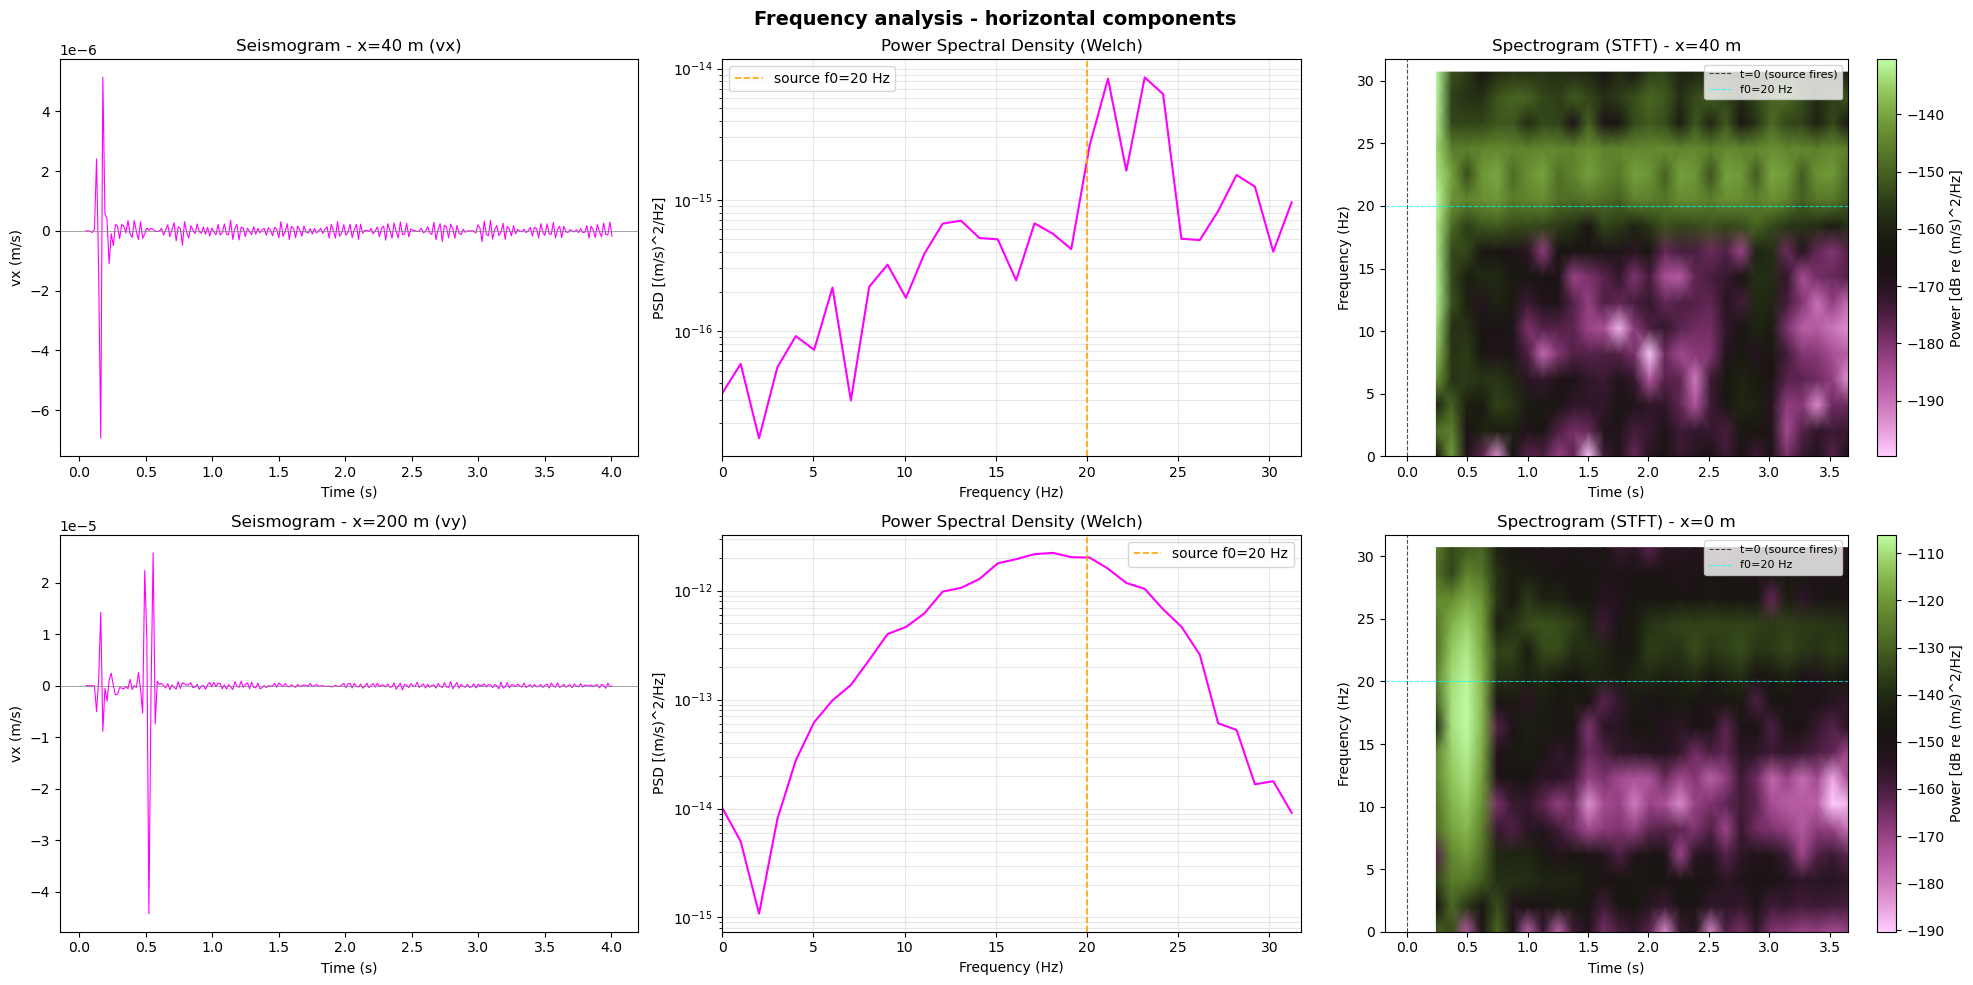

In [ ]:

# Extract traces from two receiver locations
# Receiver 1: x-index 30 (sg_vx - horizontal component)
trace_1 = sg_vx.isel({x_name: 40})
t_vals_1 = trace_1.t.values
y_vals_1 = trace_1.values

# Receiver 2: x-index 0 (sg_vy - vertical component)
trace_2 = sg_vx.isel({x_name: 200})
t_vals_2 = trace_2.t.values
y_vals_2 = trace_2.values

# dt and sampling frequency
dt = float(np.diff(t_vals_1).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

# Create 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ===== RECEIVER 1 (Horizontal component, x=150m) =====

# Row 0, Col 0: Raw seismogram
axes[0, 0].plot(t_vals_1, y_vals_1, lw=0.8, color="magenta")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("vx (m/s)")
axes[0, 0].set_title("Seismogram - x=40 m (vx)")
axes[0, 0].axhline(0, color="gray", lw=0.5)

# Row 0, Col 1: Power Spectral Density
nperseg = min(1024, len(y_vals_1) // 4)
freqs_psd_1, psd_1 = signal.welch(
    y_vals_1,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[0, 1].semilogy(freqs_psd_1, psd_1, color="magenta")
axes[0, 1].axvline(20, color="orange", lw=1.2, linestyle="--", label="source f0=20 Hz")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[0, 1].set_title("Power Spectral Density (Welch)")
axes[0, 1].set_xlim(0, fs / 2)
axes[0, 1].legend()
axes[0, 1].grid(True, which="both", alpha=0.3)

# Row 0, Col 2: Spectrogram
nperseg_stft = min(512, len(y_vals_1) // 8)
freqs_stft_1, t_stft_1, Sxx_1 = signal.spectrogram(
    y_vals_1,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_1 = 10 * np.log10(Sxx_1 + 1e-40)

im0 = axes[0, 2].pcolormesh(
    t_stft_1, freqs_stft_1, Sxx_log_1,
    shading="gouraud",
    cmap="vanimo",
)
axes[0, 2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[0, 2].axhline(20, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=20 Hz")
axes[0, 2].set_xlabel("Time (s)")
axes[0, 2].set_ylabel("Frequency (Hz)")
axes[0, 2].set_title("Spectrogram (STFT) - x=40 m")
axes[0, 2].set_ylim(0, min(100, fs / 2))
axes[0, 2].legend(loc="upper right", fontsize=8)
cbar0 = fig.colorbar(im0, ax=axes[0, 2], label="Power [dB re (m/s)^2/Hz]")

# ===== RECEIVER 2 (Vertical component, x=0m) =====

# Row 1, Col 0: Raw seismogram
axes[1, 0].plot(t_vals_2, y_vals_2, lw=0.8, color="magenta")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("vx (m/s)")
axes[1, 0].set_title("Seismogram - x=200 m (vy)")
axes[1, 0].axhline(0, color="gray", lw=0.5)

# Row 1, Col 1: Power Spectral Density
nperseg = min(1024, len(y_vals_2) // 4)
freqs_psd_2, psd_2 = signal.welch(
    y_vals_2,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[1, 1].semilogy(freqs_psd_2, psd_2, color="magenta")
axes[1, 1].axvline(20, color="orange", lw=1.2, linestyle="--", label="source f0=20 Hz")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1, 1].set_title("Power Spectral Density (Welch)")
axes[1, 1].set_xlim(0, fs / 2)
axes[1, 1].legend()
axes[1, 1].grid(True, which="both", alpha=0.3)

# Row 1, Col 2: Spectrogram
nperseg_stft = min(512, len(y_vals_2) // 8)
freqs_stft_2, t_stft_2, Sxx_2 = signal.spectrogram(
    y_vals_2,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_2 = 10 * np.log10(Sxx_2 + 1e-40)

im1 = axes[1, 2].pcolormesh(
    t_stft_2, freqs_stft_2, Sxx_log_2,
    shading="gouraud",
    cmap="vanimo",
)
axes[1, 2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[1, 2].axhline(20, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=20 Hz")
axes[1, 2].set_xlabel("Time (s)")
axes[1, 2].set_ylabel("Frequency (Hz)")
axes[1, 2].set_title("Spectrogram (STFT) - x=0 m")
axes[1, 2].set_ylim(0, min(100, fs / 2))
axes[1, 2].legend(loc="upper right", fontsize=8)
cbar1 = fig.colorbar(im1, ax=axes[1, 2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Frequency analysis - horizontal components", fontsize=14, fontweight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)
